In [137]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.c import Model_c
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [138]:
a = Model_c()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

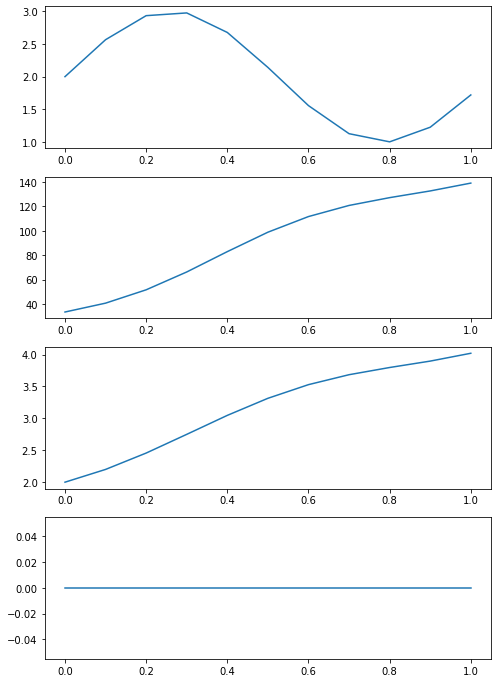

In [147]:
dur = 1.

a.params.duration = dur
a.params.mufe_init = np.array( [2.] )

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,:] += 2.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(4, figsize=(8, 12))
axes[0].plot(a.t, control1[0,0,:])
axes[1].plot(a.t, a.state["rates_exc"][0,:])
axes[2].plot(a.t, a.state["mufe"][0,:])
axes[3].plot(a.t, a.state["tau_exc"][0,:])

In [152]:
max_cntrl = 1. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 2.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(A1_bestControlA, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#4.837101271973174

set cost params
RUN  0 , total integrated cost =  4.576507682446434
RUN  1 , total integrated cost =  4.576507682446433
RUN  2 , total integrated cost =  4.576507682446432
RUN  3 , total integrated cost =  4.576507682446421
RUN  4 , total integrated cost =  4.576507682446419
RUN  5 , total integrated cost =  4.576507682446417
RUN  6 , total integrated cost =  4.576507682446414
RUN  7 , total integrated cost =  4.5765076824464135
RUN  8 , total integrated cost =  4.576507682446408
RUN  9 , total integrated cost =  4.5765076824464055
RUN  10 , total integrated cost =  4.576507682446404
RUN  11 , total integrated cost =  4.576507682446401
RUN  12 , total integrated cost =  4.576507682446398
RUN  13 , total integrated cost =  4.576507682446393
RUN  14 , total integrated cost =  4.5765076824463895
RUN  15 , total integrated cost =  4.576507682446387
RUN  16 , total integrated cost =  4.576507682446383
RUN  17 , total integrated cost =  4.576507682446381
RUN  18 , total integrated cost =  4.

[[[ 2.67020888e-01  2.65053599e-01  2.59182582e-01  2.47219253e-01
    2.27734690e-01  2.00782353e-01  1.67665070e-01  1.30071558e-01
    8.93129431e-02  4.59761555e-02 -3.13130482e-08]]]


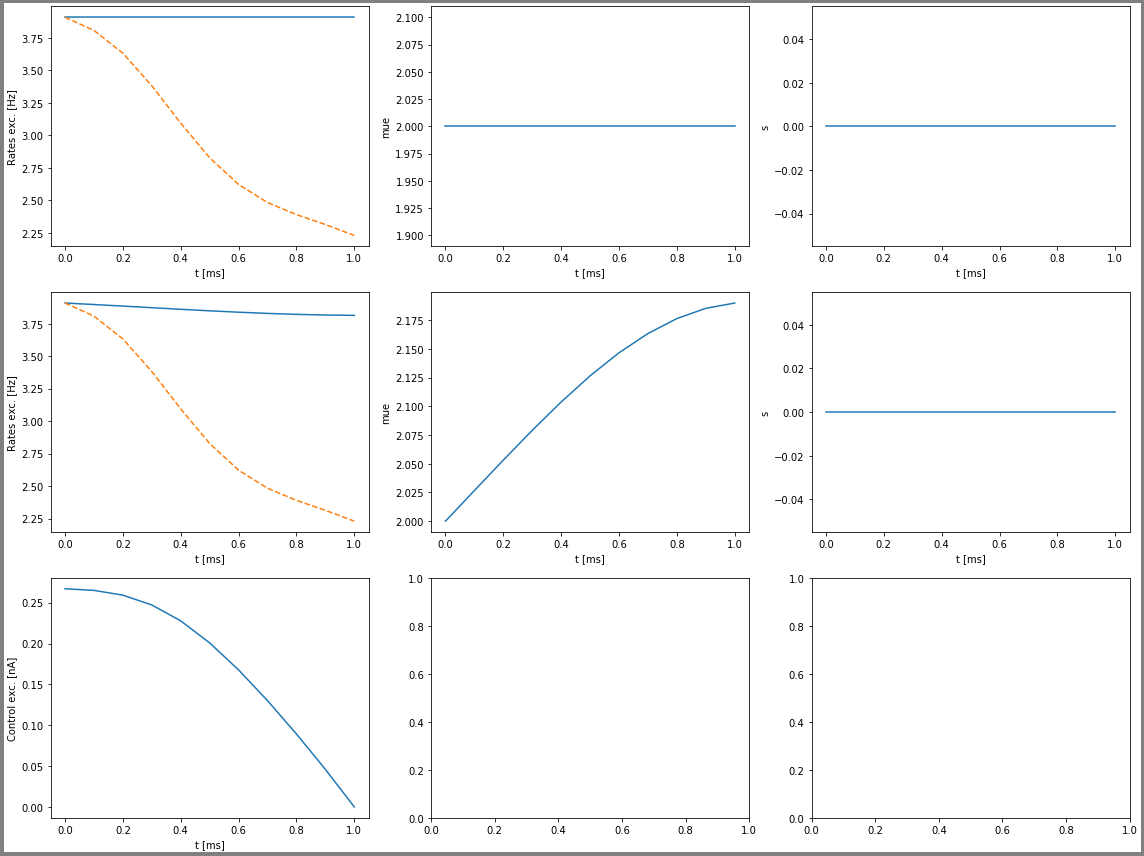

In [5]:
"""

"""

print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [155]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 20

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  4.577159497823606
change helped, counter =  3
RUN  1 , total integrated cost:  4.5770794202661
change helped, counter =  1
RUN  2 , total integrated cost:  4.5770141010549565
change helped, counter =  1
change helped, counter =  3
RUN  3 , total integrated cost:  4.576958469609325
change helped, counter =  2
change helped, counter =  4
RUN  4 , total integrated cost:  4.576909892947273
change helped, counter =  2
change helped, counter =  2
RUN  5 , total integrated cost:  4.576866543645481
change helped, counter =  3
change helped, counter =  4
RUN  6 , total integrated cost:  4.576827334623913
change helped, counter =  3
change helped, counter =  4
change helped, counter =  2
RUN  7 , total integrated cost:  4.576791434481085
change helped, counter =  1
change helped, counter =  3
RUN  8 , total integrated cost:  4.57675849936897
change helped, counter =  1
change helped, counter =  2
RUN  9 , total integrated cost:  4.576728599644502
c

[[[0.         2.6103049  2.88990456 2.9152448  2.62805642 2.1266055
   1.5843756  1.18318006 1.03040251 0.99354861 0.        ]]]


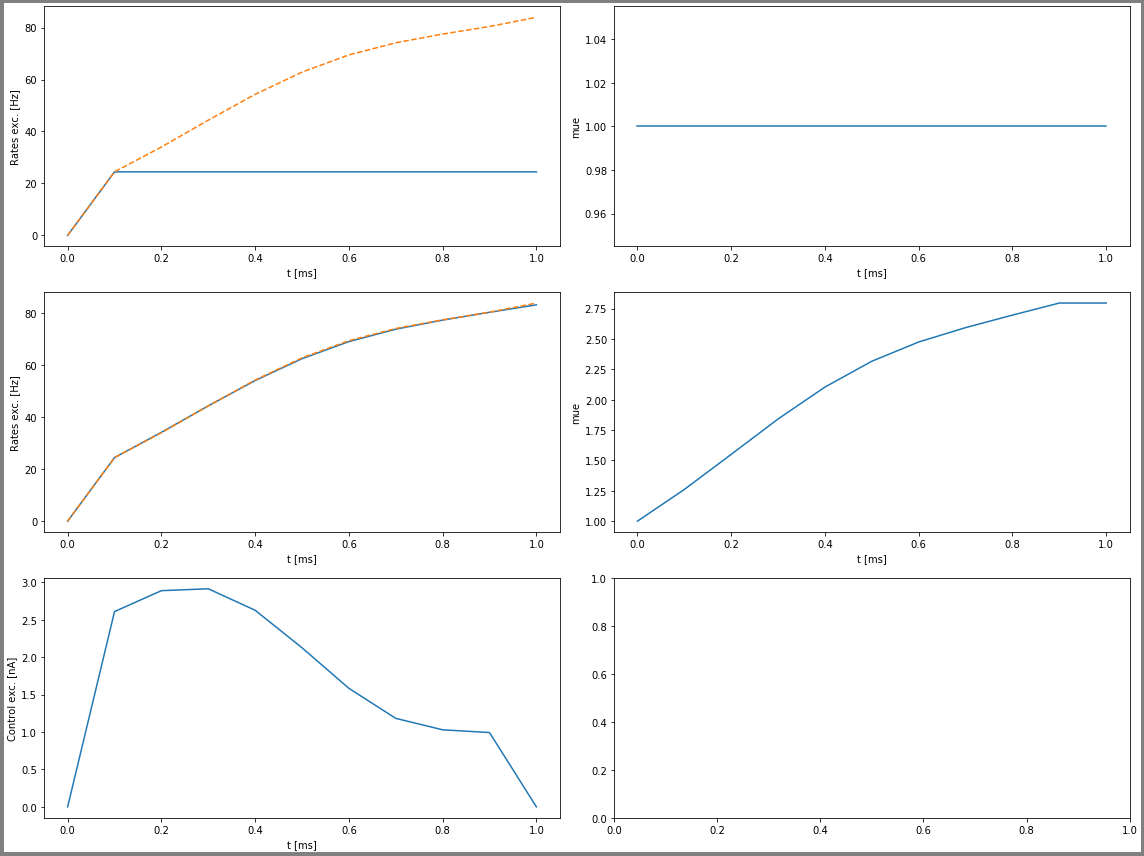

In [60]:
#0.6445150530437498
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

0.005829062948036423


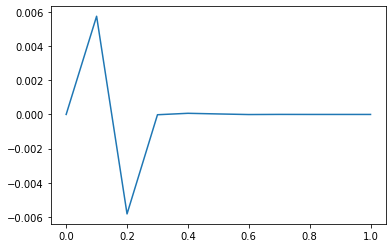

In [156]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]
print(np.amax(np.abs(diff)))

plt.plot(a.t, diff)
plt.show()

In [6]:
a = a = Model_c()
dur = 1.
a.params.duration = dur
a.params.mufe_init = 3.
control1 = a.getZeroControl()
control1[0,0,:] += 2.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))
a.run(control=control1)
        
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

2.3060903220792986e-16 0.1806409516567073
10.87666176585712
0.09093115364732157


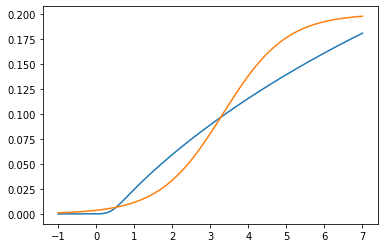

In [134]:
index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
r_min = np.amin(a.params.precalc_r[:, index_sigma_])
r_max = np.amax(a.params.precalc_r[:, index_sigma_])
print(r_min, r_max)
x_shift = - 2.
x_scale = 0.6
scaling = ( (np.tanh(x_scale * a.params.Irange[-1] + x_shift) - np.tanh(x_scale * a.params.Irange[0] + x_shift) ) /
           (a.params.precalc_r[-1,index_sigma_] - a.params.precalc_r[0,index_sigma_]) )
print(scaling)
y_shift = (a.params.precalc_r[0,index_sigma_] - np.tanh(x_scale * a.params.Irange[0] + x_shift) / scaling)
print(y_shift)
def r_func(mu):
    return 0.1 + np.tanh(x_scale * mu + x_shift) / 10. 
    return y_shift + np.tanh(x_scale * mu + x_shift) / scaling 
plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_+45])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_-15])
plt.plot(a.params.Irange, r_func(a.params.Irange) )
plt.show()

0.07393165343029298 0.07537892673717238
2589.112114820483
0.07392584339267438 2589.112114820483


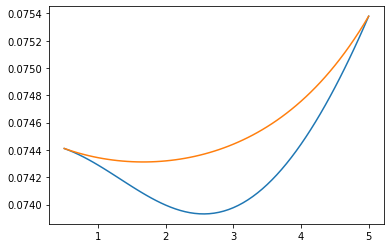

In [135]:
index_mu_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), 2.5)
r_min = np.amin(a.params.precalc_r[index_mu_, :])
r_max = np.amax(a.params.precalc_r[index_mu_, :])
print(r_min, r_max)
x_shift = -1.
x_scale = 0.6
scaling = np.abs( (np.cosh(x_scale * a.params.sigmarange[-1] + x_shift) - np.cosh(x_scale * a.params.sigmarange[0] + x_shift) ) /
           (a.params.precalc_r[index_mu_,-1] - a.params.precalc_r[index_mu_,0]) )
print(scaling)
y_shift = ( a.params.precalc_r[index_mu_,-1] - np.cosh(x_scale * a.params.sigmarange[-1] + x_shift)/ scaling)
y_dist = np.abs(a.params.precalc_r[index_mu_,0] - a.params.precalc_r[index_mu_-1,0])
print(y_shift,scaling)
def r_func_sigma(sigma):
    return y_shift + np.cosh(x_scale * sigma + x_shift) / scaling 

plt.plot(a.params.sigmarange, a.params.precalc_r[index_mu_,:])
plt.plot(a.params.sigmarange, r_func_sigma(a.params.sigmarange))
plt.show()

In [136]:
index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
r_min = np.amin(a.params.precalc_tau_mu[:, index_sigma_])
r_max = np.amax(a.params.precalc_tau_mu[:, index_sigma_])
print(r_min, r_max)
x_shift = - 2.
x_scale = 0.6
scaling = ( (np.tanh(x_scale * a.params.Irange[-1] + x_shift) - np.tanh(x_scale * a.params.Irange[0] + x_shift) ) /
           (a.params.precalc_tau_mu[-1,index_sigma_] - a.params.precalc_tau_mu[0,index_sigma_]) )
print(scaling)
y_shift = (a.params.precalc_tau_mu[0,index_sigma_] - np.tanh(x_scale * a.params.Irange[0] + x_shift) / scaling)
print(y_shift)
def tau_func(mu):
    return 0.1 + np.tanh(x_scale * mu + x_shift) / 10. 
    return y_shift + np.tanh(x_scale * mu + x_shift) / scaling 
plt.plot(a.params.Irange, a.params.precalc_tau_mu[:, index_sigma_])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_+45])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_-15])
plt.plot(a.params.Irange, tau_func(a.params.Irange) )
plt.show()

TypeError: 'NoneType' object is not subscriptable

In [69]:


gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 3 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-1):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu_up(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_mu_down(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res2 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        gradient_r[mu, sigma, 2] = res2


17450
18322
19195
20067
20940
21812
22685
23557
24430
25302
26175


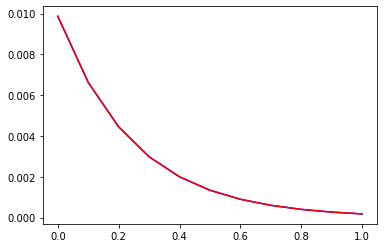

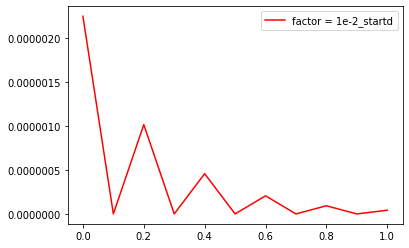

[ 2.25003216e-06 -5.58016124e-11  1.01653482e-06 -3.29114453e-11
  4.57880998e-07 -1.54149347e-11  2.05965362e-07 -6.29977366e-12
  9.25910941e-08 -8.04724869e-13  4.16129315e-08]


In [72]:
grad_r = np.zeros(( len(a.state["mufe"][0,:]) ))
grad_r_analytical = np.zeros(( len(a.state["mufe"][0,:]) ))

for m in range( len(a.t) ):
    index_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), a.state["mufe"][0,m])
    index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
    grad_r[m] = gradient_r[index_, index_sigma_, 0]
    grad_r_analytical[m] = 0.001 * (1./np.cosh(a.state["mufe"][0,m])**2)
    print(index_)
    
    
plt.plot(a.t, grad_r*1e3, c="blue")
plt.plot(a.t, grad_r_analytical*1e3, c="red")
plt.show()

factor = "1e-2_startd"
diff_grad = (grad_r_analytical - grad_r)*1e3
plt.plot(a.t, diff_grad, c="red", label=str("factor = " + factor) )
plt.legend()
plt.savefig(factor)
plt.show()

print(diff_grad)

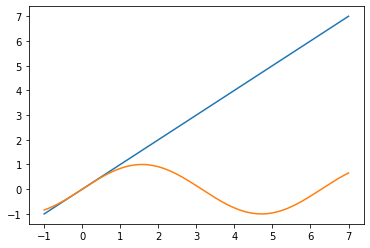

In [148]:
mu = np.arange(a.params.Irange[0],a.params.Irange[-1],a.params.dI)
lin = np.linspace(a.params.Irange[0],a.params.Irange[-1],a.params.precalc_r.shape[0])
sin = np.sin(mu)

plt.plot(mu, lin)
plt.plot(mu, sin)